# CI Test Comparison

Systematic benchmark of all built-in CI tests across four datasets and three sample sizes.
For each combination we run **CDNOTS** and **CDNOTS+** and record **F1, Precision, Recall, SHD and wall-clock time**.

CDNOTS uses the standard PC skeleton; CDNOTS+ uses a PCMCI+-style two-phase skeleton
that avoids over-conditioning.

Datasets used:

| Dataset | Variables | Max lag | Data type | Notes |
|---------|-----------|---------|-----------|-------|
| `ex1` — 5-Node Nonlinear System | 5 | 3 | Nonlinear | Squared/AR terms |
| `ex2` — 6-Node Linear VAR | 6 | 3 | Linear | Mixed lags |
| `ex3` — Cascade Network | 11 | 3 | Linear | Larger graph |
| `ex1_nonstationary` | 5+C | 2 | Nonlinear + trend | Quadratic & periodic trends; C=time node |

> **See also:** `tutorial.ipynb` for a narrative walkthrough of CDNOTS/CEDAR/GRACE with a subset of these tests.
> For mixed discrete-continuous data see `mixed_data.ipynb`; for SDE/stochastic-process data use `SigKCIGPU` (covered below).

In [6]:
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from causalts.synthetic_data.synthetic_datasets import (
    ex1_nl, ex1_nonstationary, ex2, ex3,
)
from causalts import run_cdnots, run_cdnots_plus
from causalts.grace import evaluate_graph
import causalts.plotting as tp

## Datasets

Generate at the largest T needed (T=1000) and slice for smaller T values — this ensures data is consistent across T comparisons.

In [7]:
DATASETS = {
    "ex1 (nonlinear)":       {"fn": ex1_nl,           "max_lag": 3,  "seed": 42},
    "ex2 (linear)":          {"fn": ex2,               "max_lag": 3,  "seed": 42},
    "ex3 (linear, d=11)":    {"fn": ex3,               "max_lag": 3,  "seed": 42},
    "ex1_nonstationary":       {"fn": ex1_nonstationary, "max_lag": 2,  "seed": 32},
}

T_VALUES = [200, 500] ## We are running on a MacBook, so we keep T small. You can increase this to 1000 when cuda is available.

# Generate at max T and store full result
dataset_bundles = {}
for name, cfg in DATASETS.items():
    bundle = cfg["fn"](seed=cfg["seed"], T=max(T_VALUES))
    dataset_bundles[name] = bundle
    d = bundle["df"].shape[1]
    edges = int(bundle["ground_truth"].sum())
    print(f"{name:30s}  d={d:2d}  edges={edges:2d}  max_lag={cfg['max_lag']}")

ex1 (nonlinear)                 d= 5  edges= 9  max_lag=3
ex2 (linear)                    d= 6  edges=11  max_lag=3
ex3 (linear, d=11)              d=11  edges=28  max_lag=3
ex1_nonstationary               d= 5  edges=11  max_lag=2


## Dataset Graphs

True causal graph for each dataset (neato layout). Arrows show `cause(t-lag) → effect(t)`.

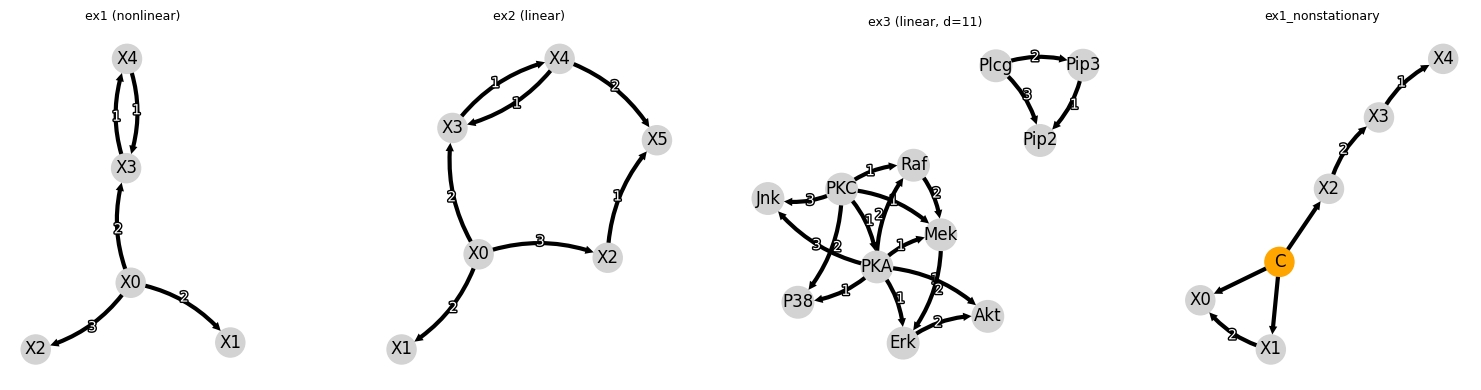

In [8]:
fig, axes = plt.subplots(1, len(DATASETS), figsize=(4 * len(DATASETS), 4))

for ax, (name, cfg) in zip(axes, DATASETS.items()):
    bundle = dataset_bundles[name]
    gt = bundle["ground_truth"]
    vnames = bundle.get("var_names", list(bundle["df"].columns))

    tp.plot_graph(
        var_names=[str(v) for v in vnames],
        graph=gt,
        fig_ax=(fig, ax),
        node_layout="neato",
        node_size=0.2,
        arrow_linewidth=3,
        show_colorbar=False,
        special_nodes={("C", 0): "orange"}
    )
    ax.set_title(name, fontsize=9)

plt.tight_layout()
plt.show()

## CI Tests

All tests share a common interface. Slow tests (`KCIGPU`, `CMIknnGPU`) are included but may be skipped at large T.

| Test | Type | Mixed data | Notes |
|------|------|-----------|-------|
| `PartialCorr` | Linear (CPU) | No | Analytic p-value, instant |
| `ParCorrGPU` | Linear (GPU) | No | Same as above, GPU path |
| `GCMIGPU` | Gaussian copula | No | Rank-normalised ParCorr — NOT a true MI estimator |
| `SplitKCIGPU` | Kernel (nonlinear) | No | 10–20× faster than KCI, best speed/F1 tradeoff |
| `DFCITGPU` | Distribution-free | **Yes** | Highest recall at small T; supports mixed discrete-continuous |
| `RCOTGPU` | Random Fourier | No | Fast at large T (> 2000) |
| `SigKCIGPU` | Signature kernel | No | Designed for stochastic processes / SDEs |
| `KCIGPU` | Kernel (full) | No | Most accurate under high collinearity — slow |
| `CMIknnGPU` | k-NN MI | No | Nonparametric baseline — slow |

> **Mixed data:** `DFCITGPU` is the only test that handles mixed discrete-continuous columns natively.
> See `mixed_data.ipynb` for a worked example.

In [ ]:
from causalts.ci_tests.parcorr    import PartialCorr
from causalts.ci_tests import ParCorrGPU
from causalts.ci_tests.gcmi_gpu   import GCMIGPU
from causalts.ci_tests import SplitKCIGPU
from causalts.ci_tests.dfcit_gpu  import DFCITGPU
from causalts.ci_tests import RCOTGPU
from causalts.ci_tests import SigKCIGPU
from causalts.ci_tests.kci_gpu    import KCIGPU
from causalts.ci_tests import CMIknnGPU

# (test_name, constructor, kwargs, skip_at_T)
CI_TESTS = [
    ("PartialCorr",  PartialCorr,  {}, None),
    ("ParCorrGPU",   ParCorrGPU,   {}, None),
    ("GCMIGPU",      GCMIGPU,      {}, None),
    ("SplitKCIGPU",  SplitKCIGPU, {}, None),
    ("DFCITGPU",     DFCITGPU,    {}, None),
    ("RCOTGPU",      RCOTGPU,     {"num_f": 100, "num_f2": 10}, None),
    ("SigKCIGPU",    SigKCIGPU,   {}, None),
    ("KCIGPU",       KCIGPU,      {"approx": "hbe"}, None),
    ("CMIknnGPU",    CMIknnGPU,   {"k": 0.2, "early_stop": True}, 1000), # skip at T>=1000
]

## Benchmark

Run CDNOTS and CDNOTS+ with each CI test on each dataset × T combination.

In [10]:
ALGOS = [
    ("CDNOTS",  run_cdnots,      {"stable": True}),
    ("CDNOTS+", run_cdnots_plus, {}),
]

results = []

for ds_name, cfg in DATASETS.items():
    bundle = dataset_bundles[ds_name]
    gt_full = bundle["ground_truth"]
    max_lag = cfg["max_lag"]
    d_df = bundle["df"].shape[1]
    gt_eval = gt_full[:d_df, :d_df, :]

    for T in T_VALUES:
        df_T = bundle["df"].iloc[:T].copy()
        data = np.ascontiguousarray(df_T.values)

        for test_name, TestCls, kwargs, skip_at in CI_TESTS:
            if skip_at is not None and T >= skip_at:
                for algo_name, _, _ in ALGOS:
                    results.append(dict(
                        dataset=ds_name, T=T, algo=algo_name, test=test_name,
                        F1=None, Precision=None, Recall=None, SHD=None, time_s=None,
                        note="skipped (too slow)"
                    ))
                continue

            for algo_name, algo_fn, algo_kwargs in ALGOS:
                try:
                    ci = TestCls(data, **kwargs)
                    t0 = time.time()
                    res = algo_fn(
                        df=df_T, indep_test=ci, num_lags=max_lag,
                        include_C=True, alpha=0.05, **algo_kwargs,
                    )
                    elapsed = time.time() - t0
                    g_tig = res.cg_tig
                    G_hat = g_tig[:d_df, :d_df, :]
                    n_lags = min(G_hat.shape[2], gt_eval.shape[2])
                    m = evaluate_graph(G_hat[:, :, :n_lags], gt_eval[:, :, :n_lags])
                    results.append(dict(
                        dataset=ds_name, T=T, algo=algo_name, test=test_name,
                        F1=round(m["F1"], 3), Precision=round(m["Precision"], 3),
                        Recall=round(m["TPR"], 3), SHD=m["SHD"],
                        time_s=round(elapsed, 1), note="",
                    ))
                    print(f"  {ds_name:28s} T={T:4d} {algo_name:7s} {test_name:12s} "
                          f"F1={m['F1']:.3f} SHD={m['SHD']:3d} PR={m['Precision']:.3f} RE={m['TPR']:.3f} ({elapsed:.2f}s)")
                except Exception as e:
                    results.append(dict(
                        dataset=ds_name, T=T, algo=algo_name, test=test_name,
                        F1=None, Precision=None, Recall=None, SHD=None, time_s=None,
                        note=f"error: {e}"
                    ))
                    print(f"  {ds_name:28s} T={T:4d} {algo_name:7s} {test_name:12s} FAILED: {e}")

df_results = pd.DataFrame(results)
print(f"\nDone: {len(df_results)} runs")

  ex1 (nonlinear)              T= 200 CDNOTS  PartialCorr  F1=0.353 SHD= 11 PR=0.375 RE=0.333 (0.14s)
  ex1 (nonlinear)              T= 200 CDNOTS+ PartialCorr  F1=0.556 SHD=  8 PR=0.556 RE=0.556 (0.07s)
  ex1 (nonlinear)              T= 200 CDNOTS  ParCorrGPU   F1=0.353 SHD= 11 PR=0.375 RE=0.333 (0.02s)
  ex1 (nonlinear)              T= 200 CDNOTS+ ParCorrGPU   F1=0.556 SHD=  8 PR=0.556 RE=0.556 (0.04s)
  ex1 (nonlinear)              T= 200 CDNOTS  GCMIGPU      F1=0.444 SHD= 10 PR=0.444 RE=0.444 (1.58s)
  ex1 (nonlinear)              T= 200 CDNOTS+ GCMIGPU      F1=0.421 SHD= 11 PR=0.400 RE=0.444 (0.44s)
  ex1 (nonlinear)              T= 200 CDNOTS  SplitKCIGPU  F1=0.500 SHD=  8 PR=0.571 RE=0.444 (3.63s)
  ex1 (nonlinear)              T= 200 CDNOTS+ SplitKCIGPU  F1=0.571 SHD=  6 PR=0.800 RE=0.444 (0.60s)
  ex1 (nonlinear)              T= 200 CDNOTS  DFCITGPU     F1=0.706 SHD=  5 PR=0.750 RE=0.667 (6.51s)
  ex1 (nonlinear)              T= 200 CDNOTS+ DFCITGPU     F1=0.435 SHD= 13 PR=0.3

## Results by Dataset

One table per dataset × algorithm, rows = CI test, columns = T value. Cells show `F1 / SHD / time(s)`.

In [11]:
for ds_name in DATASETS:
    for algo_name in [a[0] for a in ALGOS]:
        sub = df_results[(df_results["dataset"] == ds_name) & (df_results["algo"] == algo_name)]

        rows = []
        for test_name in [r[0] for r in CI_TESTS]:
            row_data = {"CI Test": test_name}
            for T in T_VALUES:
                r = sub[(sub["test"] == test_name) & (sub["T"] == T)]
                if r.empty or r.iloc[0]["F1"] is None:
                    row_data[f"T={T}"] = r.iloc[0]["note"][:10] if not r.empty else "—"
                else:
                    row_data[f"T={T}"] = f"F1={r.iloc[0]['F1']:.3f}  SHD={r.iloc[0]['SHD']}  ({r.iloc[0]['time_s']}s)"
            rows.append(row_data)

        tbl = pd.DataFrame(rows).set_index("CI Test")
        print(f"\n{'='*60}")
        print(f"Dataset: {ds_name}  |  Algorithm: {algo_name}")
        print(tbl.to_string())
        print()


Dataset: ex1 (nonlinear)  |  Algorithm: CDNOTS
                                 T=200                      T=500
CI Test                                                          
PartialCorr   F1=0.353  SHD=11  (0.1s)   F1=0.375  SHD=10  (0.2s)
ParCorrGPU    F1=0.353  SHD=11  (0.0s)   F1=0.375  SHD=10  (0.0s)
GCMIGPU       F1=0.444  SHD=10  (1.6s)    F1=0.526  SHD=9  (2.1s)
SplitKCIGPU    F1=0.500  SHD=8  (3.6s)   F1=0.571  SHD=6  (21.7s)
DFCITGPU       F1=0.706  SHD=5  (6.5s)   F1=0.667  SHD=7  (17.7s)
RCOTGPU        F1=0.667  SHD=5  (9.3s)    F1=0.526  SHD=9  (7.0s)
SigKCIGPU    F1=0.375  SHD=10  (10.3s)  F1=0.333  SHD=12  (31.2s)
KCIGPU         F1=0.571  SHD=6  (6.9s)   F1=0.588  SHD=7  (31.1s)
CMIknnGPU    F1=0.533  SHD=7  (130.9s)  F1=0.625  SHD=6  (318.7s)


Dataset: ex1 (nonlinear)  |  Algorithm: CDNOTS+
                                T=200                      T=500
CI Test                                                         
PartialCorr   F1=0.556  SHD=8  (0.1s)    F1=0.

## F1 vs T — Effect of Sample Size

For each dataset, how does each CI test's F1 improve with more data?
Solid lines = CDNOTS, dashed lines = CDNOTS+.

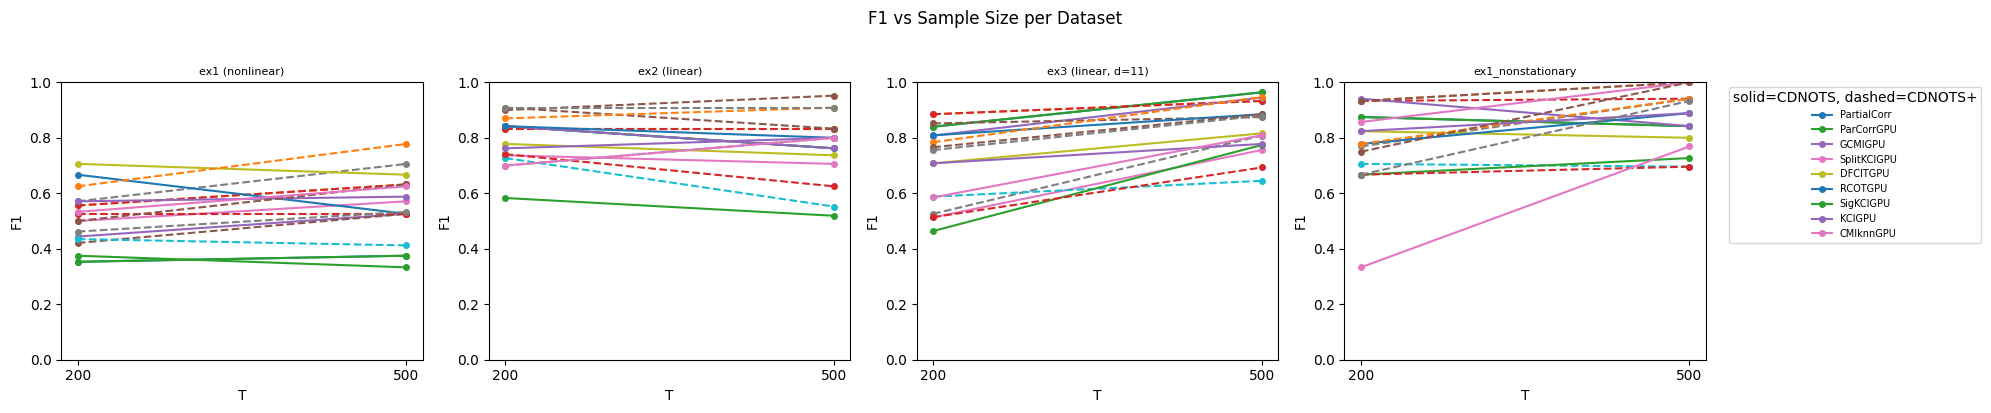

In [12]:
fig, axes = plt.subplots(1, len(DATASETS), figsize=(5 * len(DATASETS), 4), sharey=False)

algo_styles = {"CDNOTS": "-", "CDNOTS+": "--"}

for ax, ds_name in zip(axes, DATASETS):
    sub = df_results[(df_results["dataset"] == ds_name) & df_results["F1"].notna()]
    for test_name, _, _, _ in CI_TESTS:
        for algo_name, ls in algo_styles.items():
            ts_data = sub[(sub["test"] == test_name) & (sub["algo"] == algo_name)].sort_values("T")
            if ts_data.empty:
                continue
            label = f"{test_name}" if algo_name == "CDNOTS" else None
            ax.plot(ts_data["T"], ts_data["F1"], marker="o", linestyle=ls,
                    label=label, linewidth=1.5, markersize=4)
    ax.set_title(ds_name, fontsize=8)
    ax.set_xlabel("T")
    ax.set_ylabel("F1")
    ax.set_ylim(0, 1)
    ax.set_xticks(T_VALUES)

axes[-1].legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7,
                title="solid=CDNOTS, dashed=CDNOTS+")
plt.suptitle("F1 vs Sample Size per Dataset", y=1.02)
plt.tight_layout()
plt.show()

## Key Takeaways

- **Linear CI tests remain the best default.** `PartialCorr`/`ParCorrGPU` are essentially free
  and competitive with or better than far slower kernel/nonparametric tests on every dataset here,
  including the nonlinear one — reach for a nonlinear test only when a linear one clearly underfits.

- **CDNOTS+'s benefit is test-dependent, not universal.** Its MCI phase conditions each edge on
  the *whole* phase-1 parent superset rather than PC's small, adaptively-chosen sets. Tests that
  tolerate larger conditioning sets well (e.g. `RCOTGPU`, `SplitKCIGPU`) benefit from CDNOTS+;
  nonparametric tests that lose power as the conditioning set grows (notably `DFCITGPU`) can do
  markedly worse under CDNOTS+ than under plain CDNOTS. Algorithm choice and CI-test choice aren't
  independent decisions.

- **`SigKCIGPU` and `CMIknnGPU` are impractical for routine use.** `SigKCIGPU` underperforms
  consistently outside genuine SDE/path-space data; `CMIknnGPU` is 50-500× slower than the
  alternatives here for no consistent accuracy gain. Reserve both for cases with no faster
  option that works.
